In [ ]:
# Cell 1: install deps (run once)
!pip install --quiet catboost scikit-learn pandas matplotlib seaborn




   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 6.6 MB/s eta 0:00:00


In [ ]:
# Cell 2: imports & settings
import os
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
from catboost import CatBoostClassifier, Pool
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings("ignore")

RANDOM_SEED = 42
N_SPLITS = 5
USE_GPU = False   # set True if you enabled GPU in Colab runtime


In [ ]:
# Cell 3: upload / load dataset
# Option A: Use colab file picker
from google.colab import files
print("Upload your CSV file (choose the file then wait)...")
uploaded = files.upload()  # will prompt file picker
# If you uploaded multiple, pick the first uploaded filename:
fname = list(uploaded.keys())[0]
print("Loaded:", fname)
df = pd.read_csv(fname)




Upload your CSV file (choose the file then wait)...


Saving Indoor_Plant_Health_and_Growth_Factors.csv to Indoor_Plant_Health_and_Growth_Factors (1).csv
Loaded: Indoor_Plant_Health_and_Growth_Factors (1).csv


In [ ]:
# Cell 4: quick EDA (run to inspect)
display(df.head())
print("\nInfo:")
display(df.info())
print("\nMissing values (%):")
print((df.isna().mean()*100).round(3))
print("\nTarget distribution (if Health_Score exists):")
if 'Health_Score' in df.columns:
    print(df['Health_Score'].value_counts().sort_index())
else:
    print("No 'Health_Score' column found. Edit the target variable name in the code.")


,Plant_ID,Height_cm,Leaf_Count,New_Growth_Count,Health_Notes,Watering_Amount_ml,Watering_Frequency_days,Sunlight_Exposure,Room_Temperature_C,Humidity_%,...,Pest_Presence,Pest_Severity,Soil_Moisture_%,Soil_Type,Water_per_watering,Temp_Humidity_interaction,Is_Pest,Sunlight_hours,Pest_Severity_ord,Health_Score
0,Peace lily,1.59,26,3,NaN,207,3,Indirect light all day,21.91,34.7,...,Fungus gnats,Low,32.7,Clay,69.000000,760.28,1,4.0,1,4
1,Bonsai,17.45,23,3,Brown tips,182,3,6h full sun,27.77,52.4,...,NaN,NaN,27.9,Loamy,60.666667,1455.15,0,6.0,0,4
2,Begonia,15.10,23,2,Brown tips,227,4,Filtered sunlight through curtain,23.82,71.0,...,NaN,NaN,77.0,Loamy,56.750000,1691.22,0,4.0,0,4
3,Snake plant,26.94,14,3,Yellowing leaves,208,1,3h direct morning sun,27.22,68.1,...,Fungus gnats,High,17.9,Sandy,208.000000,1853.68,1,3.0,3,2
4,Spider plant,26.33,16,4,Spots,192,5,Low light corner,22.69,46.9,...,Whiteflies,NaN,26.0,Clay,38.400000,1064.16,1,4.0,0,3



Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 22 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Plant_ID                   2000 non-null   object 
 1   Height_cm                  2000 non-null   float64
 2   Leaf_Count                 2000 non-null   int64  
 3   New_Growth_Count           2000 non-null   int64  
 4   Health_Notes               1739 non-null   object 
 5   Watering_Amount_ml         2000 non-null   int64  
 6   Watering_Frequency_days    2000 non-null   int64  
 7   Sunlight_Exposure          2000 non-null   object 
 8   Room_Temperature_C         2000 non-null   float64
 9   Humidity_%                 2000 non-null   float64
 10  Fertilizer_Type            1313 non-null   object 
 11  Fertilizer_Amount_ml       2000 non-null   int64  
 12  Pest_Presence              610 non-null    object 
 13  Pest_Severity              693 non-null  

None


Missing values (%):
Plant_ID                      0.00
Height_cm                     0.00
Leaf_Count                    0.00
New_Growth_Count              0.00
Health_Notes                 13.05
Watering_Amount_ml            0.00
Watering_Frequency_days       0.00
Sunlight_Exposure             0.00
Room_Temperature_C            0.00
Humidity_%                    0.00
Fertilizer_Type              34.35
Fertilizer_Amount_ml          0.00
Pest_Presence                69.50
Pest_Severity                65.35
Soil_Moisture_%               0.00
Soil_Type                     0.00
Water_per_watering            0.00
Temp_Humidity_interaction     0.00
Is_Pest                       0.00
Sunlight_hours                0.00
Pest_Severity_ord             0.00
Health_Score                  0.00
dtype: float64

Target distribution (if Health_Score exists):
Health_Score
1     24
2    103
3    380
4    731
5    762
Name: count, dtype: int64


In [ ]:
# Cell 5: basic preprocessing & feature engineering
TARGET = 'Health_Score'
data = df.copy()

if {'Watering_Amount_ml','Watering_Frequency_days'}.issubset(data.columns):
    data['Water_per_watering'] = data['Watering_Amount_ml'] / data['Watering_Frequency_days'].replace(0,1)

if {'Room_Temperature_C','Humidity_%'}.issubset(data.columns):
    data['Temp_Humidity_interaction'] = data['Room_Temperature_C'] * data['Humidity_%']

if 'Pest_Presence' in data.columns:
    data['Is_Pest'] = (data['Pest_Presence'].fillna('None') != 'None').astype(int)
if 'Fertilizer_Type' in data.columns:
    data['Fertilizer_present'] = (data['Fertilizer_Type'].fillna('None') != 'None').astype(int)

# 4) Extract numeric hours from Sunlight_Exposure if string like "3h ..."
import re
def extract_hours(x):
    if pd.isna(x): return np.nan
    m = re.search(r'(\d+(\.\d+)?)\s*h', str(x))
    return float(m.group(1)) if m else np.nan

if 'Sunlight_Exposure' in data.columns:
    data['Sunlight_hours'] = data['Sunlight_Exposure'].apply(extract_hours)

# 5) Map Pest_Severity ordinal (optional)
if 'Pest_Severity' in data.columns:
    map_ps = {'None':0, 'Low':1, 'Moderate':2, 'High':3}
    # keep original too; CatBoost can accept categorical, but numeric ordinal can help sometimes
    data['Pest_Severity_ord'] = data['Pest_Severity'].map(map_ps).fillna(0).astype(int)


drop_list = []


print("After FE shape:", data.shape)
display(data.head(3))


After FE shape: (2000, 23)


,Plant_ID,Height_cm,Leaf_Count,New_Growth_Count,Health_Notes,Watering_Amount_ml,Watering_Frequency_days,Sunlight_Exposure,Room_Temperature_C,Humidity_%,...,Pest_Severity,Soil_Moisture_%,Soil_Type,Water_per_watering,Temp_Humidity_interaction,Is_Pest,Sunlight_hours,Pest_Severity_ord,Health_Score,Fertilizer_present
0,Peace lily,1.59,26,3,NaN,207,3,Indirect light all day,21.91,34.7,...,Low,32.7,Clay,69.000000,760.277,1,NaN,1,4,1
1,Bonsai,17.45,23,3,Brown tips,182,3,6h full sun,27.77,52.4,...,NaN,27.9,Loamy,60.666667,1455.148,0,6.0,0,4,0
2,Begonia,15.10,23,2,Brown tips,227,4,Filtered sunlight through curtain,23.82,71.0,...,NaN,77.0,Loamy,56.750000,1691.220,0,NaN,0,4,1


In [ ]:
# Cell 6: identify features and categorical columns
assert TARGET in data.columns, f"Target '{TARGET}' not found in dataframe columns."

# We'll use all columns except TARGET and columns you explicitly drop.
all_features = [c for c in data.columns if c != TARGET]

# Detect categorical columns automatically (object dtype or small-nunique)
cat_features = [c for c in all_features if data[c].dtype == 'object' or data[c].nunique() <= 20]

cat_features = [c for c in cat_features if c in all_features]

print("Num features:", len(all_features))
print("Categorical features detected (will pass to CatBoost):", cat_features)
print("Sample feature list:", all_features[:20])


Num features: 22
Categorical features detected (will pass to CatBoost): ['Plant_ID', 'New_Growth_Count', 'Health_Notes', 'Watering_Frequency_days', 'Sunlight_Exposure', 'Fertilizer_Type', 'Pest_Presence', 'Pest_Severity', 'Soil_Type', 'Is_Pest', 'Sunlight_hours', 'Pest_Severity_ord', 'Fertilizer_present']
Sample feature list: ['Plant_ID', 'Height_cm', 'Leaf_Count', 'New_Growth_Count', 'Health_Notes', 'Watering_Amount_ml', 'Watering_Frequency_days', 'Sunlight_Exposure', 'Room_Temperature_C', 'Humidity_%', 'Fertilizer_Type', 'Fertilizer_Amount_ml', 'Pest_Presence', 'Pest_Severity', 'Soil_Moisture_%', 'Soil_Type', 'Water_per_watering', 'Temp_Humidity_interaction', 'Is_Pest', 'Sunlight_hours']


In [ ]:
# Cell 7 (REPLACEMENT): prepare data and ensure correct label mapping
import numpy as np

# Use same 'data' variable from earlier FE cell and TARGET name
ALL_FEATURES = [c for c in data.columns if c != TARGET]

# Detect categorical features (strings or small cardinality)
cat_features = [c for c in ALL_FEATURES if data[c].dtype == 'object' or data[c].nunique() <= 20]

# Make X and original y
X = data[ALL_FEATURES].copy()
y_orig = data[TARGET].copy()

print("Target value counts:")
print(y_orig.value_counts().sort_index())

# Ensure y is integer series
print("Target dtype:", y_orig.dtype)

# Map labels to 0..K-1 safely
unique_labels = sorted(y_orig.unique())
label_to_idx = {lab: i for i, lab in enumerate(unique_labels)}
idx_to_label = {i: lab for lab, i in label_to_idx.items()}
print("\nLabel mapping (original -> index):", label_to_idx)

# Convert y
y = y_orig.map(label_to_idx).astype(int)

print("\nAfter mapping, target counts (0..K-1):")
print(y.value_counts().sort_index())

# Convert categorical features to string (CatBoost prefers str categories)
for c in cat_features:
    X[c] = X[c].astype(str).fillna('nan')

# Fill numeric NaNs
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
X[num_cols] = X[num_cols].fillna(X[num_cols].median())

print("\nX shape:", X.shape, "y shape:", y.shape)
print("Cat features passed to CatBoost:", cat_features)


Target value counts:
Health_Score
1     24
2    103
3    380
4    731
5    762
Name: count, dtype: int64
Target dtype: int64

Label mapping (original -> index): {np.int64(1): 0, np.int64(2): 1, np.int64(3): 2, np.int64(4): 3, np.int64(5): 4}

After mapping, target counts (0..K-1):
Health_Score
0     24
1    103
2    380
3    731
4    762
Name: count, dtype: int64

X shape: (2000, 22) y shape: (2000,)
Cat features passed to CatBoost: ['Plant_ID', 'New_Growth_Count', 'Health_Notes', 'Watering_Frequency_days', 'Sunlight_Exposure', 'Fertilizer_Type', 'Pest_Presence', 'Pest_Severity', 'Soil_Type', 'Is_Pest', 'Sunlight_hours', 'Pest_Severity_ord', 'Fertilizer_present']



--- Fold 1 ---
0:	learn: 1.5618297	test: 1.5636375	best: 1.5636375 (0)	total: 442ms	remaining: 14m 43s
200:	learn: 0.4524697	test: 0.7461622	best: 0.7461622 (200)	total: 56.8s	remaining: 8m 28s
400:	learn: 0.2490265	test: 0.7232577	best: 0.7232577 (400)	total: 1m 46s	remaining: 7m 4s
600:	learn: 0.1619893	test: 0.7235086	best: 0.7220276 (522)	total: 2m 37s	remaining: 6m 6s
Stopped by overfitting detector  (150 iterations wait)

bestTest = 0.7220275513
bestIteration = 522

Shrink model to first 523 iterations.
Fold 1  Accuracy: 0.6800  Macro-F1: 0.4333

--- Fold 2 ---
0:	learn: 1.5583642	test: 1.5625533	best: 1.5625533 (0)	total: 430ms	remaining: 14m 18s
200:	learn: 0.4623388	test: 0.7387307	best: 0.7387307 (200)	total: 47.1s	remaining: 7m 1s
400:	learn: 0.2484974	test: 0.7028065	best: 0.7026454 (397)	total: 1m 35s	remaining: 6m 20s
600:	learn: 0.1616626	test: 0.6942214	best: 0.6938670 (591)	total: 2m 23s	remaining: 5m 34s
800:	learn: 0.1125232	test: 0.6922644	best: 0.6915670 (779)	tot

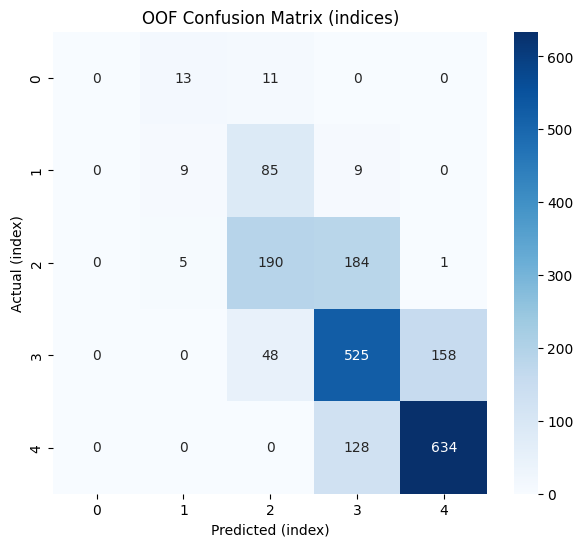


Top features (feature importance):


,feature,importance
0,Water_per_watering,16.719922
1,Soil_Moisture_%,10.701375
2,Health_Notes,9.963149
3,Pest_Severity_ord,8.300222
4,Room_Temperature_C,6.264330
5,Pest_Severity,5.816316
6,Soil_Type,5.114924
7,Fertilizer_Type,4.989746
8,Watering_Frequency_days,4.791604
9,New_Growth_Count,3.854919


In [ ]:
# Cell 8 (REPLACEMENT): CV training (labels 0..K-1), evaluate, and show feature importance
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
from catboost import Pool, CatBoostClassifier
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

N_SPLITS = 5
RANDOM_SEED = 42
USE_GPU = False  # set True if GPU runtime

skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_SEED)

oof_preds = np.zeros((len(X), len(np.unique(y))))   # class probabilities
oof_labels = np.zeros(len(X), dtype=int)
fold_scores = []

models = []
for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y), 1):
    print(f"\n--- Fold {fold} ---")
    X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]

    train_pool = Pool(X_tr, y_tr, cat_features=cat_features)
    val_pool = Pool(X_val, y_val, cat_features=cat_features)

    model = CatBoostClassifier(
        iterations=2000,
        learning_rate=0.05,
        depth=8,
        loss_function='MultiClass',
        eval_metric='MultiClass',
        random_seed=RANDOM_SEED,
        early_stopping_rounds=150,
        verbose=200,
        task_type='GPU' if USE_GPU else 'CPU'
    )
    model.fit(train_pool, eval_set=val_pool, use_best_model=True)

    # Predict probabilities (no +1 adjustments; labels are 0..K-1)
    val_probs = model.predict_proba(X_val)
    val_pred_idx = np.argmax(val_probs, axis=1)   # 0..K-1 predicted indices

    oof_preds[val_idx] = val_probs
    oof_labels[val_idx] = val_pred_idx

    acc = accuracy_score(y_val, val_pred_idx)
    f1 = f1_score(y_val, val_pred_idx, average='macro')
    fold_scores.append((acc, f1))
    print(f"Fold {fold}  Accuracy: {acc:.4f}  Macro-F1: {f1:.4f}")

    models.append(model)
    model.save_model(f"catboost_fold{fold}.cbm")

# CV summary
mean_acc = np.mean([s[0] for s in fold_scores])
mean_f1  = np.mean([s[1] for s in fold_scores])
print("\nMean CV Accuracy: {:.4f}  Mean CV Macro-F1: {:.4f}".format(mean_acc, mean_f1))

# Compute overall metrics on OOF
from sklearn.metrics import classification_report, confusion_matrix
print("\nOverall OOF Accuracy:", accuracy_score(y, oof_labels))
print("Overall OOF Macro-F1:", f1_score(y, oof_labels, average='macro'))
print("\nClassification report (indexes 0..K-1):")
print(classification_report(y, oof_labels, digits=4))

# Confusion matrix (indexes 0..K-1)
cm = confusion_matrix(y, oof_labels, labels=sorted(y.unique()))
plt.figure(figsize=(7,6))
import seaborn as sns
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted (index)")
plt.ylabel("Actual (index)")
plt.title("OOF Confusion Matrix (indices)")
plt.show()

# Feature importances (from last fold model)
fi = models[-1].get_feature_importance(prettified=True)
fi_df = pd.DataFrame(fi)
fi_df.columns = ['feature','importance']
fi_df = fi_df.sort_values('importance', ascending=False).head(30)
print("\nTop features (feature importance):")
display(fi_df)


Overall Accuracy: 0.679
Overall Macro-F1: 0.4303859373343094

Classification report:
              precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000        24
           1     0.3333    0.0874    0.1385       103
           2     0.5689    0.5000    0.5322       380
           3     0.6206    0.7182    0.6658       731
           4     0.7995    0.8320    0.8154       762

    accuracy                         0.6790      2000
   macro avg     0.4645    0.4275    0.4304      2000
weighted avg     0.6567    0.6790    0.6623      2000



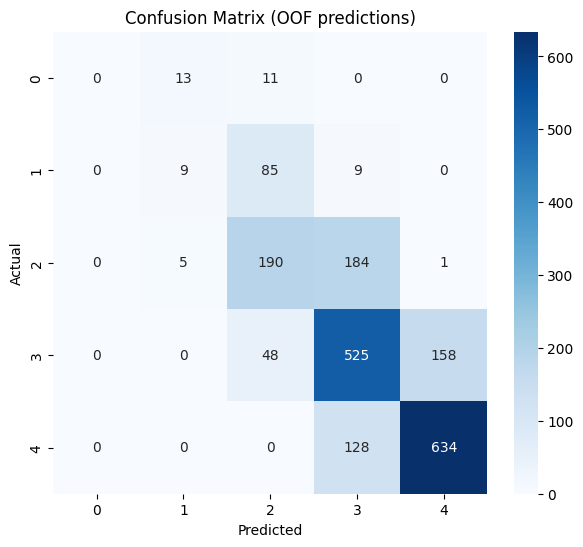

In [ ]:
# Cell 9: Overall OOF metrics & confusion matrix
# Make sure label mapping matches. If your labels are 1..K, adjust:
oof_pred_labels = oof_labels.astype(int)
print("Overall Accuracy:", accuracy_score(y, oof_pred_labels))
print("Overall Macro-F1:", f1_score(y, oof_pred_labels, average='macro'))
print("\nClassification report:")
print(classification_report(y, oof_pred_labels, digits=4))

# Confusion matrix plot
cm = confusion_matrix(y, oof_pred_labels, labels=sorted(y.unique()))
plt.figure(figsize=(7,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=sorted(y.unique()), yticklabels=sorted(y.unique()))
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (OOF predictions)")
plt.show()

In [ ]:
# Cell 10: Train final CatBoost on FULL dataset (short version)
from catboost import CatBoostClassifier, Pool
from collections import Counter
import joblib

TARGET = 'Health_Score'
all_features = [c for c in data.columns if c != TARGET]

# Categorical features
cat_features = [c for c in all_features if data[c].dtype=='object' or data[c].nunique()<=20]

# Prepare X, y
X = data[all_features].copy()
y = data[TARGET].astype(int)

# Ensure categorical types
for c in cat_features:
    X[c] = X[c].astype(str).fillna('nan')

# Fill numeric missing
num_cols = X.select_dtypes(include=[np.number]).columns
X[num_cols] = X[num_cols].fillna(X[num_cols].median())

# Class weights for imbalance
freq = Counter(y)
classes = sorted(freq.keys())
total = len(y)
class_weights = [total / (len(classes) * freq[c]) for c in classes]

print("Class frequencies:", freq)
print("Class weights:", class_weights)

# Final CatBoost model
final_model = CatBoostClassifier(
    iterations=570,
    learning_rate=0.05,
    depth=8,
    loss_function='MultiClass',
    eval_metric='MultiClass',
    class_weights=class_weights,
    random_seed=42,
    verbose=200
)

pool = Pool(X, y, cat_features=cat_features)
final_model.fit(pool)

# Save model + metadata
final_model.save_model("catboost_final_full.cbm")
joblib.dump({'features': all_features, 'cat_features': cat_features}, "catboost_metadata.joblib")

print("Model saved as catboost_final_full.cbm")

# Quick train evaluation (not generalization metric)
preds = final_model.predict(X).astype(int)
from sklearn.metrics import accuracy_score, f1_score, classification_report
print("\nTrain Accuracy:", accuracy_score(y, preds))
print("Train Macro-F1:", f1_score(y, preds, average='macro'))
print("\nClassification Report:\n", classification_report(y, preds))


Class frequencies: Counter({5: 762, 4: 731, 3: 380, 2: 103, 1: 24})
Class weights: [16.666666666666668, 3.883495145631068, 1.0526315789473684, 0.5471956224350205, 0.5249343832020997]
0:	learn: 1.5599799	total: 572ms	remaining: 5m 25s
200:	learn: 0.4080277	total: 52.3s	remaining: 1m 35s
400:	learn: 0.2408434	total: 1m 43s	remaining: 43.6s
569:	learn: 0.1810421	total: 2m 28s	remaining: 0us
Model saved as catboost_final_full.cbm

Train Accuracy: 0.87
Train Macro-F1: 0.8779463668414677

Classification Report:
               precision    recall  f1-score   support

           1       0.95      0.88      0.91        24
           2       0.85      0.89      0.87       103
           3       0.84      0.89      0.87       380
           4       0.85      0.83      0.84       731
           5       0.90      0.90      0.90       762

    accuracy                           0.87      2000
   macro avg       0.88      0.88      0.88      2000
weighted avg       0.87      0.87      0.87      2000
